# Задание 1: очистка кредитного портфеля

Выполнила: Стрюкова

**Задача.** В выгрузке `loan_portfolio.csv` попадается мусор: дубли, пропуски, битые даты, значения вне справочников и расхождения бизнес-логики. Нужно аккуратно все вычистить и каждое решение зафиксировать в журнале, чтобы очистку можно было воспроизвести и объяснить заказчику.

**Рамки кейса.** Берем только кредиты, выданные в 2023–2024 гг. Регионы: Moscow, SPb, Ural, Siberia, South. Каналы продаж: branch, online, partner. Продукты: consumer, car, renovation, education. Дефолтом считаем просрочку 90+ дней (DPD).

In [1]:
import numpy as np
import pandas as pd
from datetime import datetime

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

AUTHOR = 'Striukova_Anastasia_Stanislavovna' 

# исходная выгрузка: 20 колонок — анкета заемщика, условия договора и поведение по платежам
df = pd.read_csv('loan_portfolio.csv')
print('до чистки:', df.shape)
df.head(3)

до чистки: (6031, 20)


,loan_id,client_id,issue_date,age,gender,monthly_income,employment_type,work_experience_years,region,channel,loan_product,loan_amount,loan_term_months,interest_rate,monthly_payment,credit_score,existing_loans_count,dti_ratio,days_past_due,is_default
0,1,16795,2023-05-01,59,M,86602.0,self_employed,34.1,Ural,branch,renovation,480000,48,17.1,13875.0,696.0,0,49.2,0,0
1,2,1860,2023-02-23,27,F,45955.0,freelance,8.1,South,online,consumer,160000,6,19.7,28220.0,654.0,3,62.0,10,0
2,3,77820,2023-11-27,30,M,72578.0,freelance,11.2,SPb,online,renovation,470000,36,19.1,17252.0,588.0,4,77.7,203,1


## 0. Осмотр данных

In [2]:
# прежде чем что-то чистить, смотрим типы и где вообще есть пустые значения
df.info()
df.isna().sum()[lambda s: s > 0]  # колонки, в которых реально есть пропуски

<class 'pandas.DataFrame'>
RangeIndex: 6031 entries, 0 to 6030
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   loan_id                6031 non-null   int64  
 1   client_id              6031 non-null   int64  
 2   issue_date             6031 non-null   str    
 3   age                    6031 non-null   int64  
 4   gender                 6031 non-null   str    
 5   monthly_income         6021 non-null   float64
 6   employment_type        6031 non-null   str    
 7   work_experience_years  6026 non-null   float64
 8   region                 6031 non-null   str    
 9   channel                6031 non-null   str    
 10  loan_product           6031 non-null   str    
 11  loan_amount            6031 non-null   int64  
 12  loan_term_months       6031 non-null   int64  
 13  interest_rate          6031 non-null   float64
 14  monthly_payment        6031 non-null   float64
 15  credit_score   

monthly_income           10
work_experience_years     5
credit_score              5
dtype: int64

## 1. Журнал очистки

In [3]:
# Все правки пишем в журнал: что нашли, сколько строк задето и какое решение приняли.
# В конце соберем его в отдельный csv — так историю очистки можно показать ревизору.
journal = []

def add_note(step, what_found, n_rows, decision, why=''):
    """Одна запись журнала очистки."""
    journal.append({
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'step_name': step,
        'anomaly_type': what_found,
        'rows_affected': n_rows,
        'action_taken': decision,
        'comment': why,
    })

## 2. Дубликаты номеров договоров

In [4]:
# loan_id — номер кредитного договора в АБС, он обязан быть уникальным.
# Повторы обычно появляются при склейке нескольких выгрузок в один файл.
repeated_ids = int(df['loan_id'].duplicated().sum())

if repeated_ids:
    df = df.drop_duplicates(subset='loan_id', keep='first')
    add_note('Дубликаты', 'Повторные loan_id', repeated_ids, 'Удалены',
             'Оставили первое вхождение договора')
else:
    add_note('Дубликаты', 'Повторные loan_id', 0, 'Проверка пройдена',
             'Все номера договоров уникальны')

print('строк после удаления дублей:', len(df))

строк после удаления дублей: 5988


## 3. Пропуски

In [5]:
# Неполная анкета для риск-моделирования бесполезна: импутация в обязательных
# полях внесет шум в оценки PD, поэтому строки с любым пропуском считаем браком
# выгрузки и убираем целиком.
rows_with_gaps = df.isna().any(axis=1)

if rows_with_gaps.sum():
    df = df.loc[~rows_with_gaps]
    add_note('Пропуски', 'Строки с незаполненными полями', int(rows_with_gaps.sum()),
             'Удалены', 'Импутация не применялась: пропуск трактуем как сбой ввода')
else:
    add_note('Пропуски', 'Строки с незаполненными полями', 0,
             'Проверка пройдена', 'Пропусков в датасете нет')

print('осталось строк:', len(df))

осталось строк: 5988


## 4. Даты выдачи

In [6]:
# Дату выдачи переводим в datetime; все, что не распарсилось, считаем битой строкой.
# Затем отрезаем все вне окна кейса (01.01.2023–31.12.2024): туда обычно попадают
# тестовые записи и хвосты старой выгрузки.
df['issue_date'] = pd.to_datetime(df['issue_date'], errors='coerce')

unparsed = int(df['issue_date'].isna().sum())
if unparsed:
    df = df.dropna(subset=['issue_date'])
    add_note('Даты', 'Нечитаемый формат issue_date', unparsed, 'Удалены',
             'to_datetime с errors=coerce не распознал значение')
else:
    add_note('Даты', 'Нечитаемый формат issue_date', 0, 'Проверка пройдена',
             'Все даты читаются корректно')

PERIOD_START = pd.Timestamp('2023-01-01')  # левая граница кейса
PERIOD_END = pd.Timestamp('2024-12-31')    # правая граница кейса

outside_window = int(((df['issue_date'] < PERIOD_START) | (df['issue_date'] > PERIOD_END)).sum())
if outside_window:
    df = df[(df['issue_date'] >= PERIOD_START) & (df['issue_date'] <= PERIOD_END)]
    add_note('Даты', 'Выдачи вне периода 2023–2024', outside_window, 'Удалены',
             'По условию кейса работаем только с выдачами 2023–2024 гг.')
else:
    add_note('Даты', 'Выдачи вне периода 2023–2024', 0, 'Проверка пройдена',
             'Все выдачи внутри целевого окна')

## 5. Справочники: регион, канал, продукт

In [7]:
# Допустимые значения берем из справочников кейса. Все, что в них не входит,
# — опечатки оператора либо значения из других бизнес-линий, которые к нашему
# портфелю не относятся.
catalogues = {
    'region': {'Moscow', 'SPb', 'Ural', 'Siberia', 'South'},
    'channel': {'branch', 'online', 'partner'},
    'loan_product': {'consumer', 'car', 'renovation', 'education'},
}

for field, allowed in catalogues.items():
    offside = ~df[field].isin(allowed)
    if offside.any():
        df = df.loc[~offside]
        add_note('Категории', f'Значения {field} вне справочника', int(offside.sum()),
                 'Удалены', 'Оставлены только значения из справочника')
    else:
        add_note('Категории', f'Значения {field} вне справочника', 0,
                 'Проверка пройдена', 'Значения соответствуют справочнику')

# контроль: в колонках должны остаться только разрешенные значения
for field in catalogues:
    print(field, '->', sorted(df[field].unique()))

region -> ['Moscow', 'SPb', 'Siberia', 'South', 'Ural']
channel -> ['branch', 'online', 'partner']
loan_product -> ['car', 'consumer', 'education', 'renovation']


## 6. Бизнес-логика: DPD и флаг дефолта

В банке действует правило: дефолт — просрочка 90+ дней (ориентир на стандарты Базеля III и 590-П ЦБ РФ). Флаг `is_default` — производный от `days_past_due`, поэтому при расхождении верим DPD, а флаг пересчитываем. Отрицательная просрочка физического смысла не имеет — это ошибка переноса данных.

In [8]:
# сначала смотрим таблицу сопряженности: сразу видно, где DPD противоречит флагу
print(pd.crosstab(df['days_past_due'] >= 90, df['is_default'],
                  rownames=['DPD >= 90'], colnames=['is_default']))

conflict_90plus = int(((df['days_past_due'] >= 90) & (df['is_default'] != 1)).sum())
conflict_current = int(((df['days_past_due'] < 90) & (df['is_default'] != 0)).sum())
conflicts = conflict_90plus + conflict_current

if conflicts:
    # источник истины — DPD, флаг пересчитываем от него
    df.loc[df['days_past_due'] >= 90, 'is_default'] = 1
    df.loc[df['days_past_due'] < 90, 'is_default'] = 0
    add_note('Бизнес-логика', 'Расхождение DPD и is_default', conflicts, 'Исправлено',
             'is_default пересчитан по правилу: 90+ дней просрочки = дефолт')
else:
    add_note('Бизнес-логика', 'Расхождение DPD и is_default', 0, 'Проверка пройдена',
             'Флаг дефолта согласован с глубиной просрочки')

# отрицательная просрочка физически невозможна — значит, поле перепутали при переносе
negative_dpd = int((df['days_past_due'] < 0).sum())
if negative_dpd:
    df = df.loc[df['days_past_due'] >= 0]
    add_note('Бизнес-логика', 'Отрицательный days_past_due', negative_dpd, 'Удалены',
             'Отрицательная просрочка физического смысла не имеет')
else:
    add_note('Бизнес-логика', 'Отрицательный days_past_due', 0, 'Проверка пройдена', '')

is_default     0     1
DPD >= 90             
False       4789     0
True           0  1199


## 7. Возраст, доход и экстремальные значения

In [9]:
# Возрастные рамки — продуктовая политика банка: выдаем с 18 лет, верхняя
# граница 80 лет. Все, что выпадает из диапазона, — ошибка в анкете.
weird_age = (df['age'] < 18) | (df['age'] > 80)
if weird_age.any():
    df = df.loc[~weird_age]
    add_note('Выбросы', 'Возраст вне диапазона 18–80', int(weird_age.sum()), 'Удалены',
             'Нарушены продуктовые ограничения по возрасту')
else:
    add_note('Выбросы', 'Возраст вне диапазона 18–80', 0, 'Проверка пройдена', '')

# Доход не может быть нулевым или отрицательным: с таким доходом кредит просто не выдали бы
nonpositive_income = int((df['monthly_income'] <= 0).sum())
if nonpositive_income:
    df = df.loc[df['monthly_income'] > 0]
    add_note('Выбросы', 'Доход <= 0', nonpositive_income, 'Удалены',
             'Похоже на перепутанный знак или незаполненное поле')
else:
    add_note('Выбросы', 'Доход <= 0', 0, 'Проверка пройдена', '')

# Экстремумы не выкидываем, а ограничиваем на 1-м и 99-м перцентилях. Вариант
# просто удалить хвосты я рассматривала, но так мы потеряем реальных клиентов
# (VIP, зарплатные проекты) — они редкие, но для портфеля важные.
for col in ['monthly_income', 'loan_amount', 'monthly_payment', 'credit_score']:
    lo, hi = df[col].quantile([0.01, 0.99])
    n_clipped = int(((df[col] < lo) | (df[col] > hi)).sum())

    df[col] = df[col].clip(lower=lo, upper=hi)

    if n_clipped:
        add_note('Выбросы', f'Экстремальные значения: {col}', n_clipped,
                 'Ограничение перцентилем 1-99', 'Хвосты подтянуты до перцентилей, строки сохранены')
    else:
        add_note('Выбросы', f'Экстремальные значения: {col}', 0, 'Проверка пройдена', '')

## 8. Формат чисел

In [10]:
# Деньги — с копейками (2 знака), кредитный рейтинг — целое число, ставка и DTI —
# 2 знака, стаж — 1 знак. Так датасет выглядит как нормальная банковская витрина.
money_fields = ['monthly_income', 'loan_amount', 'monthly_payment']
df[money_fields] = df[money_fields].round(2)

df['credit_score'] = df['credit_score'].round(0).astype(int)
df['interest_rate'] = df['interest_rate'].round(2)
df['dti_ratio'] = df['dti_ratio'].round(2)
df['work_experience_years'] = df['work_experience_years'].round(1)
df['age'] = df['age'].astype(int)

df.head()

,loan_id,client_id,issue_date,age,gender,monthly_income,employment_type,work_experience_years,region,channel,loan_product,loan_amount,loan_term_months,interest_rate,monthly_payment,credit_score,existing_loans_count,dti_ratio,days_past_due,is_default
0,1,16795,2023-05-01,59,M,86602.0,self_employed,34.1,Ural,branch,renovation,480000,48,17.1,13875.0,696,0,49.2,0,0
1,2,1860,2023-02-23,27,F,45955.0,freelance,8.1,South,online,consumer,160000,6,19.7,28220.0,654,3,62.0,10,0
2,3,77820,2023-11-27,30,M,72578.0,freelance,11.2,SPb,online,renovation,470000,36,19.1,17252.0,588,4,77.7,203,1
3,4,55886,2023-08-29,27,M,68792.0,self_employed,7.7,Ural,partner,consumer,240000,36,20.1,8931.0,642,3,59.2,31,0
4,5,7265,2024-06-13,60,F,93397.0,freelance,40.4,Siberia,branch,consumer,280000,36,20.2,10434.0,582,2,63.2,179,1


## 9. Сохраняем артефакты

In [11]:
# три файла: отчет об очистке и очищенные данные с логом очистки

import textwrap
import matplotlib.pyplot as plt

journal_df = pd.DataFrame(journal)

def column_with_error(err):
    """Какой столбец содержит ошибка, исходя из описания аномалии."""
    error = str(err)
    if 'Экстремальные значения:' in error:
        return error.split(':', 1)[1].strip()
    if 'вне справочника' in error:
        return error.split('Значения')[-1].replace('вне справочника', '').strip()
    if 'loan_id' in error:
        return 'loan_id'
    if 'незаполненн' in error:
        return 'все столбцы'
    if 'issue_date' in error or 'вне периода' in error:
        return 'issue_date'
    if 'DPD' in error and 'is_default' in error:
        return 'days_past_due, is_default'
    if 'Отрицательный' in error:
        return 'days_past_due'
    if 'Возраст' in error:
        return 'age'
    if 'Доход' in error:
        return 'monthly_income'
    return '—'

report = pd.DataFrame({
    '№': range(1, len(journal_df) + 1),
    'Ошибка': journal_df['anomaly_type'].values,
    'Столбец с ошибкой': [column_with_error(a) for a in journal_df['anomaly_type']],
    'Количество случаев': journal_df['rows_affected'].values,
    'Действие': journal_df['action_taken'].values,
    'Обоснование действия': [c if (pd.notna(c) and str(c).strip()) else '—'
                             for c in journal_df['comment']],
})

WRAP_WIDTH = {'№': 4, 'Ошибка': 26, 'Столбец с ошибкой': 16,
              'Количество случаев': 11, 'Действие': 18, 'Обоснование действия': 38}

def wrap_text(t, width):
    lines = []
    for part in str(t).split('\n'):
        lines.extend(textwrap.wrap(part, width=width) or [''])
    return '\n'.join(lines)

headers = list(report.columns)
cell_text, row_lines = [], []
for _, r in report.iterrows():
    wrapped = [wrap_text(r[h], WRAP_WIDTH[h]) for h in headers]
    row_lines.append(max(w.count('\n') + 1 for w in wrapped))
    cell_text.append(wrapped)

header_text = [wrap_text(h, WRAP_WIDTH[h]) for h in headers]
head_lines = max(w.count('\n') + 1 for w in header_text)
total_lines = head_lines + sum(row_lines)

LINE_IN = 0.23
fig, ax = plt.subplots(figsize=(14, total_lines * LINE_IN + 0.7))
ax.axis('off')
ax.set_title('Журнал очистки данных', fontsize=12, weight='bold', pad=12)

tbl = ax.table(cellText=cell_text, colLabels=header_text,
               colWidths=[0.04, 0.20, 0.15, 0.11, 0.16, 0.34],
               cellLoc='left', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)

for (row, col), cell in tbl.get_celld().items():
    cell.set_height((head_lines if row == 0 else row_lines[row - 1]) / total_lines)
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#dce6f1')
    if col in (0, 3):
        cell.get_text().set_horizontalalignment('center')

fig.savefig(f"cleaning_log_{AUTHOR}.pdf", bbox_inches='tight', dpi=150)
plt.close(fig)

log_df = pd.DataFrame(report)
log_df.to_csv(f"cleaning_log_{AUTHOR}.csv", index=False)
df.to_csv(f"loan_portfolio_clean_{AUTHOR}.csv", index=False)

## 10. Финальная проверка

In [12]:
# Прогоняем итоговые инварианты. Если что-то из этого упадет, значит чистка
# где-то сломалась и файл заказчику отдавать нельзя.
logic_breakage = (
    ((df['days_past_due'] >= 90) & (df['is_default'] == 0)).sum()
    + ((df['days_past_due'] < 90) & (df['is_default'] == 1)).sum()
)

assert df['loan_id'].is_unique, 'встречаются повторные номера договоров'
assert logic_breakage == 0, 'флаг дефолта не согласован с DPD'
assert df.isna().sum().sum() == 0, 'в данных остались пропуски'
assert (df['days_past_due'] >= 0).all(), 'осталась отрицательная просрочка'
assert df['issue_date'].min() >= PERIOD_START, 'есть выдачи раньше 2023 года'
assert df['issue_date'].max() <= PERIOD_END, 'есть выдачи позже 2024 года'

default_rate = df['is_default'].mean() * 100

print(f'Итоговый размер: {df.shape[0]} строк, {df.shape[1]} колонок')
print(f'Уровень дефолтности (PD): {default_rate:.2f}%')
print('Все инварианты выполнены — датасет готов к анализу.')

Итоговый размер: 5988 строк, 20 колонок
Уровень дефолтности (PD): 20.02%
Все инварианты выполнены — датасет готов к анализу.


## Итог

Получили чистый портфель в границах кейса: без дублей, пропусков и мусорных справочных значений, с согласованным флагом дефолта и подрезанными хвостами распределений. Все решения задокументированы в `cleaning_log_Striukova.csv` — по нему можно восстановить историю любой правки.

# Задание 2. Описание бизнес-процесса

In [13]:
business_process = pd.DataFrame([
    {
        "Шаг процесса": "Привлечение клиента",
        "Входные данные": "Канал (branch / online / partner), регион, продукт (consumer / car / renovation / education)",
        "Исполнители": "Маркетинг / Продажи",
        "Выходной результат": "Заявка клиента"
    },
    {
        "Шаг процесса": "Сбор данных по клиенту",
        "Входные данные": "Заявка, анкета (возраст, доход, занятость, стаж), данные бюро (credit_score, DTI)",
        "Исполнители": "Андеррайтинг / Скоринг",
        "Выходной результат": "Профиль клиента и параметры кредита"
    },
    {
        "Шаг процесса": "Первичный скоринг",
        "Входные данные": "credit_score, dti_ratio, monthly_income, employment_type",
        "Исполнители": "Риск-менеджмент",
        "Выходной результат": "Решение: одобрить / отклонить / ручной андеррайтинг"
    },
    {
        "Шаг процесса": "Андеррайтинг и назначение условий",
        "Входные данные": "Скоринговый результат, loan_amount, loan_term_months, interest_rate",
        "Исполнители": "Андеррайтинг",
        "Выходной результат": "Одобренные условия кредита"
    },
    {
        "Шаг процесса": "Выдача кредита",
        "Входные данные": "Одобренная заявка",
        "Исполнители": "Операционный блок",
        "Выходной результат": "Активный кредит (loan_amount, issue_date, monthly_payment)"
    },
    {
        "Шаг процесса": "Мониторинг портфеля",
        "Входные данные": "Платежная дисциплина клиента",
        "Исполнители": "Риск-мониторинг / Collection",
        "Выходной результат": "Статус кредита: current / overdue / default"
    },
    {
        "Шаг процесса": "Работа с просроченной задолженностью",
        "Входные данные": "days_past_due",
        "Исполнители": "Collection / Проблемная задолженность",
        "Выходной результат": "Дефолт is_default = 1 при DPD >= 90"
    },
    {
        "Шаг процесса": "Оценка доходности и рисков",
        "Входные данные": "loan_portfolio_clean, branch_reference",
        "Исполнители": "Финансы / Бизнес-анализ / Риск",
        "Выходной результат": "Отчет по доходности, EL, план-факту"
    }
])

file_name = f"business_process_{AUTHOR}.csv"
business_process.to_csv(file_name, index=False, encoding="utf-8-sig")

print(f"Файл сохранен: {file_name}")
business_process

Файл сохранен: business_process_Striukova_Anastasia_Stanislavovna.csv


,Шаг процесса,Входные данные,Исполнители,Выходной результат
0,Привлечение клиента,"Канал (branch / online / partner), регион, про...",Маркетинг / Продажи,Заявка клиента
1,Сбор данных по клиенту,"Заявка, анкета (возраст, доход, занятость, ста...",Андеррайтинг / Скоринг,Профиль клиента и параметры кредита
2,Первичный скоринг,"credit_score, dti_ratio, monthly_income, emplo...",Риск-менеджмент,Решение: одобрить / отклонить / ручной андерра...
3,Андеррайтинг и назначение условий,"Скоринговый результат, loan_amount, loan_term_...",Андеррайтинг,Одобренные условия кредита
4,Выдача кредита,Одобренная заявка,Операционный блок,"Активный кредит (loan_amount, issue_date, mont..."
5,Мониторинг портфеля,Платежная дисциплина клиента,Риск-мониторинг / Collection,Статус кредита: current / overdue / default
6,Работа с просроченной задолженностью,days_past_due,Collection / Проблемная задолженность,Дефолт is_default = 1 при DPD >= 90
7,Оценка доходности и рисков,"loan_portfolio_clean, branch_reference",Финансы / Бизнес-анализ / Риск,"Отчет по доходности, EL, план-факту"


# Задание 3. Анализ кредитного портфеля

Выполнила: Стрюкова Анастасия Станиславовна.

Задача: разобраться, что влияет на дефолтность, найти проблемные сегменты,
посчитать ожидаемые убытки и сравнить факт с планом по филиалам.

Работаю с очищенным датасетом из первого этапа.

In [14]:
import numpy as np
import seaborn as sns
from scipy import stats

df = pd.read_csv(f"loan_portfolio_clean_{AUTHOR}.csv")
df['issue_date'] = pd.to_datetime(df['issue_date'])

# LGD берем 45% — стандарт для необеспеченной розницы
# (в реальном банке это пришло бы от подразделения взыскания)
LGD = 0.45

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

# Утилитарная функция. Понадобится позже
def print_title(msg, width=80, char="-"):
    print("\n" + char * width)
    print(msg)
    print(char * width)

In [15]:
# первый взгляд на портфель
print(f"Кредитов в портфеле: {len(df)}")
print(f"Фактическая PD: {df['is_default'].mean()*100:.2f}%")
print(f"Средний чек: {df['loan_amount'].mean():,.0f} руб.")
print(f"Средняя ставка: {df['interest_rate'].mean():.2f}%")
print(f"Период выдач: с {df['issue_date'].min().date()} по {df['issue_date'].max().date()}")

df.select_dtypes(include=[np.number]).describe().round(2)

Кредитов в портфеле: 5988
Фактическая PD: 20.02%
Средний чек: 403,500 руб.
Средняя ставка: 17.73%
Период выдач: с 2023-01-01 по 2024-12-30


,loan_id,client_id,age,monthly_income,work_experience_years,loan_amount,loan_term_months,interest_rate,monthly_payment,credit_score,existing_loans_count,dti_ratio,days_past_due,is_default
count,5988.00,5988.00,5988.00,5988.00,5988.00,5988.00,5988.00,5988.00,5988.00,5988.00,5988.00,5988.00,5988.00,5988.0
mean,2996.92,50152.15,36.52,79493.83,14.18,403500.33,36.16,17.73,16721.74,630.46,1.48,56.43,42.44,0.2
std,1730.68,28657.49,12.19,30561.85,12.25,246318.96,15.44,2.17,11430.92,73.62,1.27,14.33,63.02,0.4
min,1.00,1055.00,19.00,19511.02,0.00,80000.00,6.00,11.90,2979.27,440.00,0.00,17.00,0.00,0.0
25%,1498.50,25203.00,27.00,59343.50,3.30,220000.00,24.00,16.00,8793.00,582.00,0.00,45.90,3.00,0.0
50%,2997.50,49884.50,34.00,77106.50,12.00,340000.00,36.00,17.90,13706.50,633.00,1.00,55.30,15.00,0.0
75%,4494.25,75523.00,45.00,98044.75,22.10,530000.00,48.00,19.30,21102.50,682.00,2.00,66.20,34.00,0.0
max,6000.00,99989.00,67.00,164928.69,45.00,1260000.00,60.00,24.90,63747.20,793.00,5.00,84.80,278.00,1.0


## 1. Дефолтность по срезам

Сначала смотрю PD по регионам, каналам и продуктам — чтобы понять, где вообще проблемы.

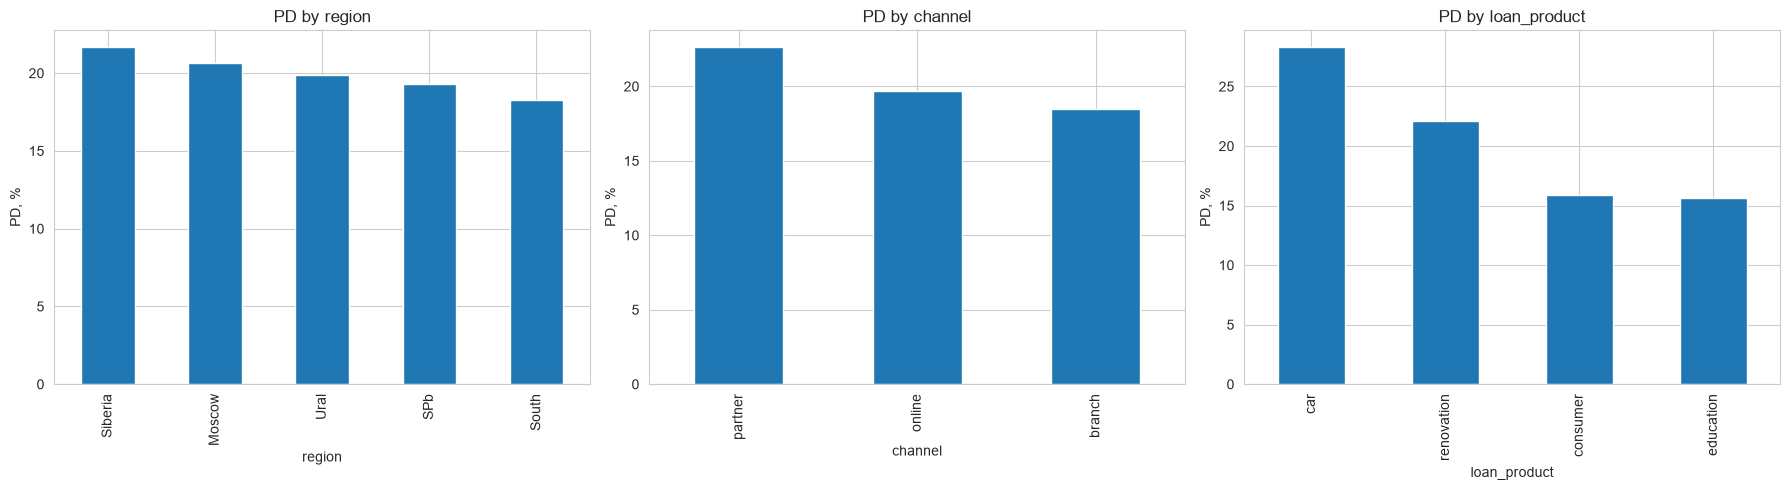

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['region', 'channel', 'loan_product']):
    (df.groupby(col)['is_default'].mean() * 100).sort_values(ascending=False).plot.bar(ax=ax)
    ax.set_title(f"PD by {col}")
    ax.set_ylabel("PD, %")

plt.tight_layout()
plt.show()

In [17]:
# смотрю по занятости и возрасту
# по занятости — сортирую чтобы сразу видеть кто хуже
emp_pd = (df.groupby('employment_type')['is_default'].mean() * 100).sort_values(ascending=False)
print("PD по занятости:")
print(emp_pd.round(2))

# возраст бинную: <25, 25-40, 40-55, 55+
# right=False => интервалы вида [0,25), [25,40) и тд
bins = [0, 25, 40, 55, 100]
labels = ['<25', '25-40', '40-55', '55+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

age_pd = (df.groupby('age_group', observed=False)['is_default'].mean() * 100).round(2)
print("\nPD по возрасту:")
print(age_pd)

# винтажи по кварталам — чтобы увидеть нет ли шоков
df['quarter'] = df['issue_date'].dt.to_period('Q')
q_pd = (df.groupby('quarter')['is_default'].mean() * 100).round(2)
print("\nPD по кварталам:")
print(q_pd)

PD по занятости:
employment_type
unemployed       58.55
freelance        25.00
self_employed    18.84
employed         12.47
Name: is_default, dtype: float64

PD по возрасту:
age_group
<25      24.90
25-40    20.28
40-55    18.72
55+      13.97
Name: is_default, dtype: float64

PD по кварталам:
quarter
2023Q1    20.86
2023Q2    19.81
2023Q3    20.08
2023Q4    21.07
2024Q1    20.70
2024Q2    18.65
2024Q3    19.08
2024Q4    20.00
Freq: Q-DEC, Name: is_default, dtype: float64


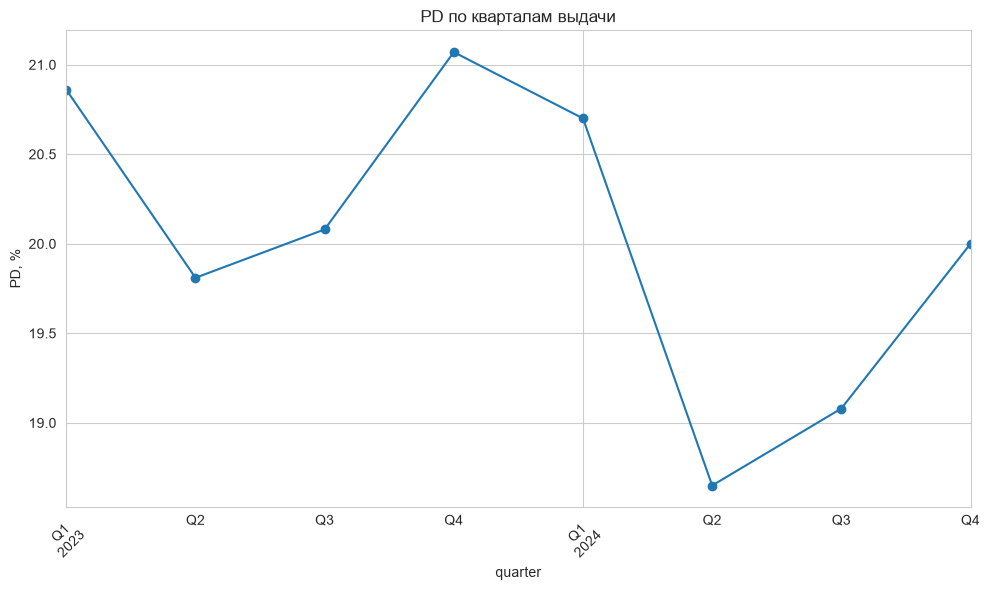

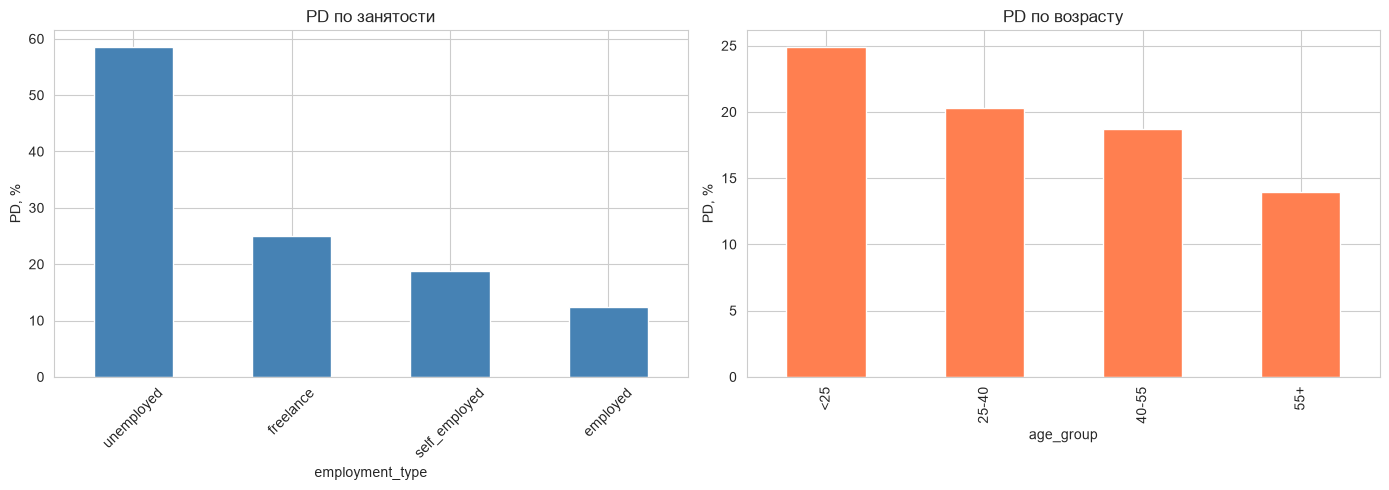

In [18]:
# визуализирую винтажи
q_pd.plot.line(marker='o')
plt.title("PD по кварталам выдачи")
plt.ylabel("PD, %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# и сравнение по занятости / возрасту
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
emp_pd.plot.bar(ax=axes[0], color='steelblue')
axes[0].set_title("PD по занятости")
axes[0].set_ylabel("PD, %")
axes[0].tick_params(axis='x', rotation=45)

age_pd.plot.bar(ax=axes[1], color='coral')
axes[1].set_title("PD по возрасту")
axes[1].set_ylabel("PD, %")

plt.tight_layout()
plt.show()

## 2. Корреляции

Пирсон ловит только линейные связи, но для первого взгляда подойдет.
Для финального скоринга буду смотреть IV/WoE.

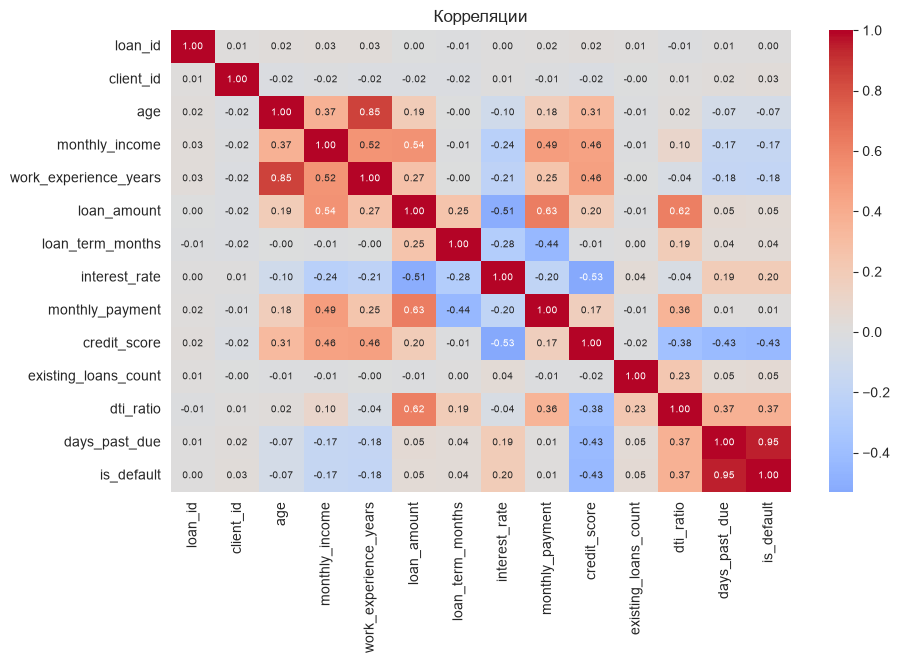

In [19]:
corr = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, annot_kws={"size": 7})
plt.title("Корреляции")
plt.show()

# NB: корреляция Пирсона не поймает монотонные нелинейные зависимости.
# Для скоринговой карты нужен IV.

## 3. Credit score — насколько он реально разделяет

Гипотеза: у дефолтных скоринг ниже. Проверяю.

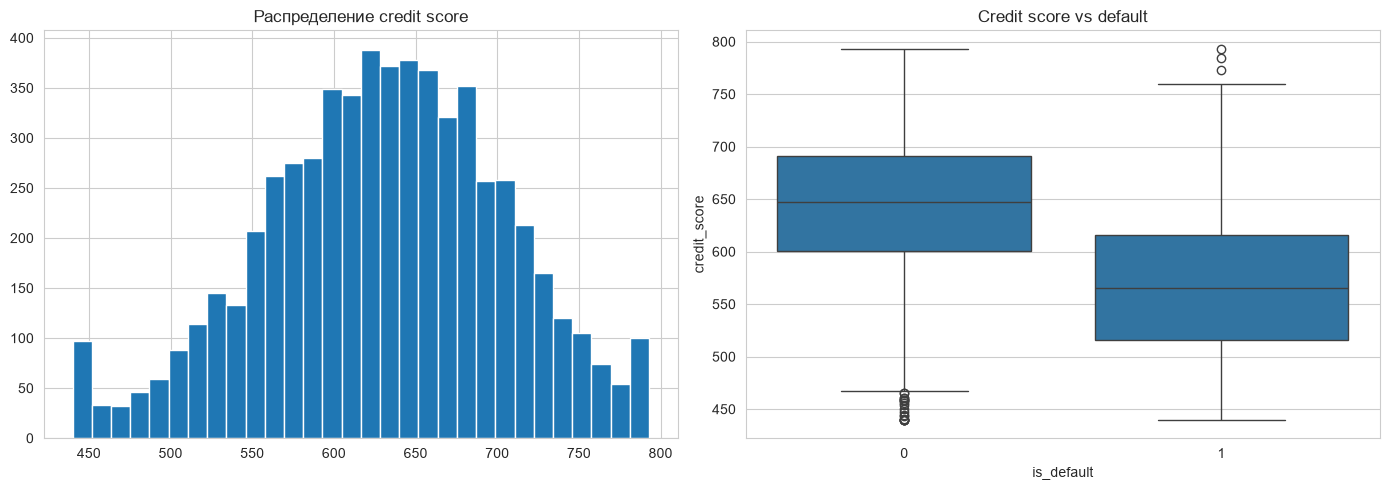

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# распределение
df['credit_score'].hist(bins=30, ax=axes[0])
axes[0].set_title("Распределение credit score")

# boxplot по дефолту — видна ли разница медиан
sns.boxplot(x='is_default', y='credit_score', data=df, ax=axes[1])
axes[1].set_title("Credit score vs default")

plt.tight_layout()
plt.show()

## 4. Rule-based сегментация

Пороги взяла экспертно (FICO-бенчмарки + стандарты DTI).
В реальном банке это калибровал бы риск-менеджмент через backtest.

risk_segment
HIGH    37.43
LOW      2.15
MED      9.42
Name: is_default, dtype: float64


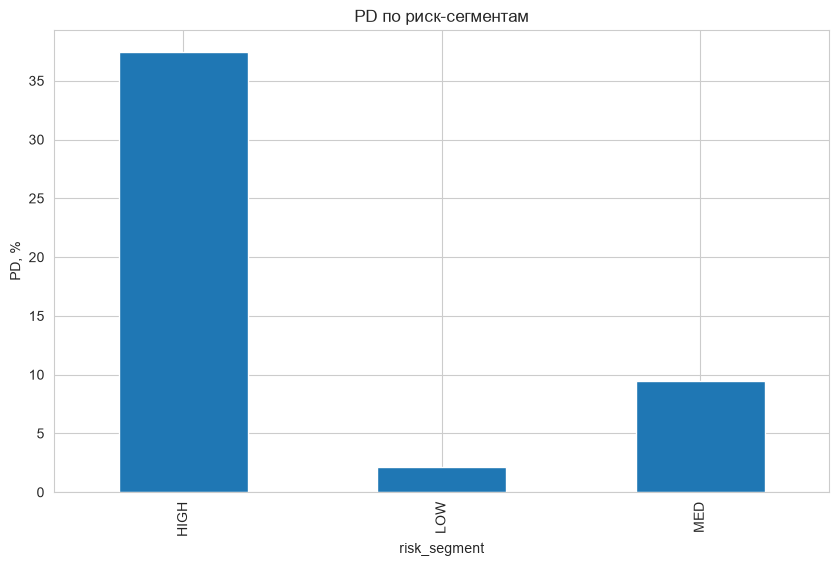

In [21]:
def risk_segment(row):
    if row['credit_score'] >= 670 and row['dti_ratio'] <= 50:
        return 'LOW'
    if row['credit_score'] < 600 or row['dti_ratio'] >= 70:
        return 'HIGH'
    return 'MED'

df['risk_segment'] = df.apply(risk_segment, axis=1)

# sanity check: PD должна расти от LOW к HIGH
seg_pd = (df.groupby('risk_segment')['is_default'].mean() * 100).round(2)
print(seg_pd)

seg_pd.plot.bar()
plt.title("PD по риск-сегментам")
plt.ylabel("PD, %")
plt.show()

## 5. Статпроверки гипотез

- Доход и credit score — t-test (различаются ли средние у дефолтных/недефолтных)
- Канал и регион — хи-квадрат (зависит ли дефолт от категории)

NB: t-test чувствителен к ненормальности. Для robust-подхода лучше Манн-Уитни,
но для первичной оценки и так сойдет.

In [22]:
ALPHA = 0.05

# H1: доход у дефолтных ниже
inc_0 = df[df['is_default'] == 0]['monthly_income']
inc_1 = df[df['is_default'] == 1]['monthly_income']
t_stat, p_inc = stats.ttest_ind(inc_0, inc_1)
print(f"T-test income: p={p_inc:.4f} -> {'различается' if p_inc < ALPHA else 'не различается'}")

# H2: credit_score у дефолтных ниже
sc_0 = df[df['is_default'] == 0]['credit_score']
sc_1 = df[df['is_default'] == 1]['credit_score']
t_stat2, p_sc = stats.ttest_ind(sc_0, sc_1)
print(f"T-test credit_score: p={p_sc:.4f} -> {'различается' if p_sc < ALPHA else 'не различается'}")

# H3: канал влияет на дефолт
chi2_ch, p_ch, _, _ = stats.chi2_contingency(pd.crosstab(df['channel'], df['is_default']))
print(f"Chi2 channel: p={p_ch:.4f} -> {'зависит' if p_ch < ALPHA else 'не зависит'}")

# H4: регион влияет
chi2_rg, p_rg, _, _ = stats.chi2_contingency(pd.crosstab(df['region'], df['is_default']))
print(f"Chi2 region: p={p_rg:.4f} -> {'зависит' if p_rg < ALPHA else 'не зависит'}")

T-test income: p=0.0000 -> различается
T-test credit_score: p=0.0000 -> различается
Chi2 channel: p=0.0080 -> зависит
Chi2 region: p=0.4024 -> не зависит


## 6. Кросс-анализ регион × канал

Хочу найти конкретные «горячие точки», которые маскируются при анализе по одному фактору.

PD по region × channel, %
channel  branch  online  partner
region                          
Moscow    18.24   20.29    24.31
SPb       17.83   19.11    21.67
Siberia   18.75   23.02    23.48
South     18.27   17.12    20.38
Ural      19.57   18.78    21.86


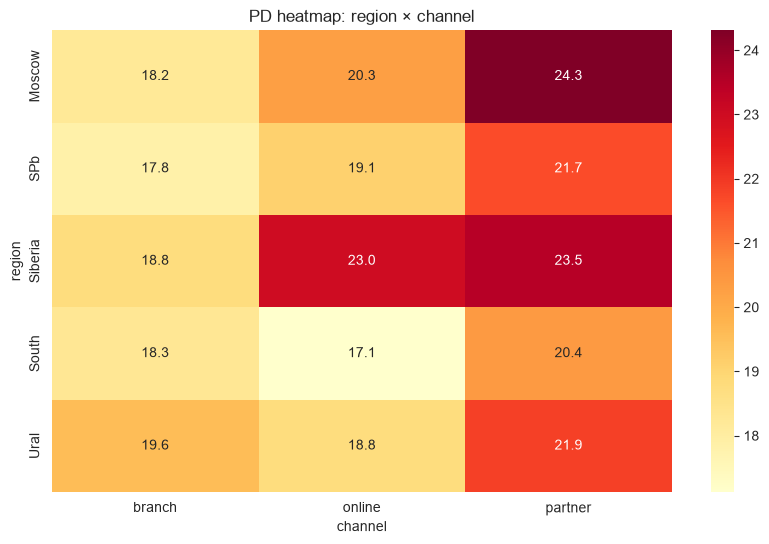

In [23]:
cross_pd = df.pivot_table(
    values='is_default',
    index='region',
    columns='channel',
    aggfunc='mean'
) * 100

print("PD по region × channel, %")
print(cross_pd.round(2))

sns.heatmap(cross_pd, annot=True, fmt=".1f", cmap='YlOrRd')
plt.title("PD heatmap: region × channel")
plt.show()

PD South+partner: 20.38%
PD остальные:     20.01%
t-test p-value: 0.8964 -> незначимо


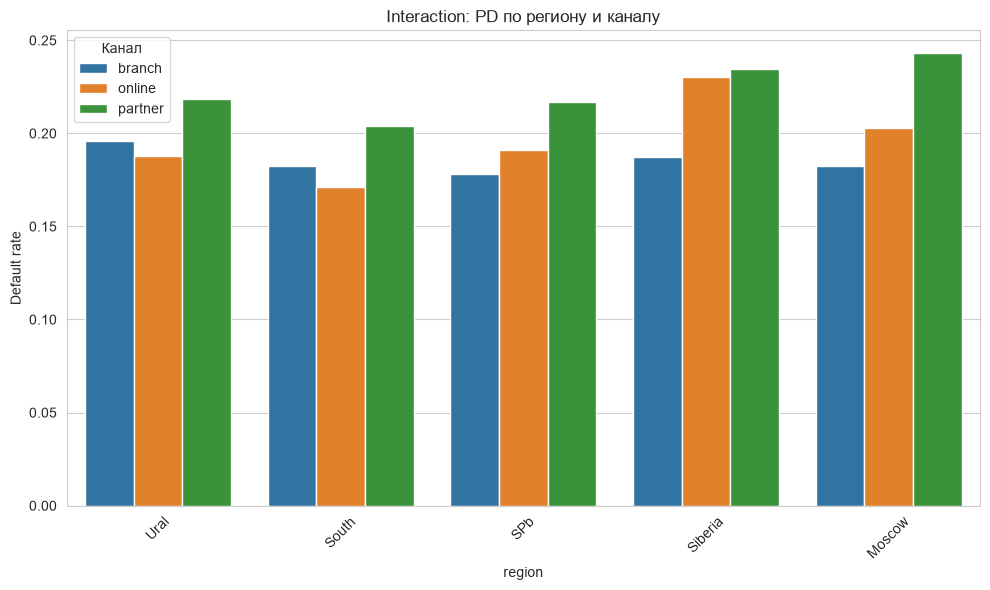

In [24]:
# South+partner выглядит подозрительно — проверяю статистически
df['south_partner'] = ((df['region'] == 'South') & (df['channel'] == 'partner')).astype(int)

sp = df[df['south_partner'] == 1]['is_default']
other = df[df['south_partner'] == 0]['is_default']
print(f"PD South+partner: {sp.mean()*100:.2f}%")
print(f"PD остальные:     {other.mean()*100:.2f}%")

# Welch t-test (не предполагает равных дисперсий)
t_stat, p_val = stats.ttest_ind(sp, other, equal_var=False)
print(f"t-test p-value: {p_val:.4f} -> {'значимо' if p_val < 0.05 else 'незначимо'}")

# визуализирую interaction
plt.figure(figsize=(10, 6))
sns.barplot(x='region', y='is_default', hue='channel', data=df, errorbar=None)
plt.title("Interaction: PD по региону и каналу")
plt.ylabel("Default rate")
plt.legend(title='Канал')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7. Логистическая регрессия

Не для прогноза, а чтобы посмотреть коэффициенты — какие факторы сильнее тянут в дефолт.
Стандартизирую признаки чтобы коэффициенты были сопоставимы.

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')  # чтобы convergence warnings не засоряли вывод

num_cols = ['age', 'monthly_income', 'loan_amount', 'interest_rate', 'credit_score', 'dti_ratio']
cat_cols = ['region', 'channel', 'loan_product', 'employment_type']

X_num = df[num_cols].copy()
# one-hot, drop_first чтобы избежать dummy trap
X_cat = pd.get_dummies(df[cat_cols], drop_first=True, dtype=int)

X = pd.concat([X_num, X_cat], axis=1)
y = df['is_default']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_scaled, y)

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_[0]
}).sort_values('coef', key=abs, ascending=False)

print("Топ-15 факторов дефолта:")
print(coef_df.head(15).round(3))

# отдельно посмотрю на регионы и каналы
print("\nКоэффициенты region:")
print(coef_df[coef_df['feature'].str.startswith('region_')].round(3))
print("\nКоэффициенты channel:")
print(coef_df[coef_df['feature'].str.startswith('channel_')].round(3))

Топ-15 факторов дефолта:
                          feature   coef
5                       dti_ratio  0.925
4                    credit_score -0.852
12          loan_product_consumer -0.190
3                   interest_rate  0.183
17     employment_type_unemployed  0.182
2                     loan_amount -0.148
1                  monthly_income  0.076
14        loan_product_renovation -0.075
8                    region_South -0.071
7                  region_Siberia -0.053
11                channel_partner  0.040
9                     region_Ural -0.035
15      employment_type_freelance  0.024
0                             age -0.018
16  employment_type_self_employed  0.017

Коэффициенты region:
          feature   coef
8    region_South -0.071
7  region_Siberia -0.053
9     region_Ural -0.035
6      region_SPb -0.007

Коэффициенты channel:
            feature   coef
11  channel_partner  0.040
10   channel_online  0.007


# График топ факторов дефолта по итогам логистической регрессии

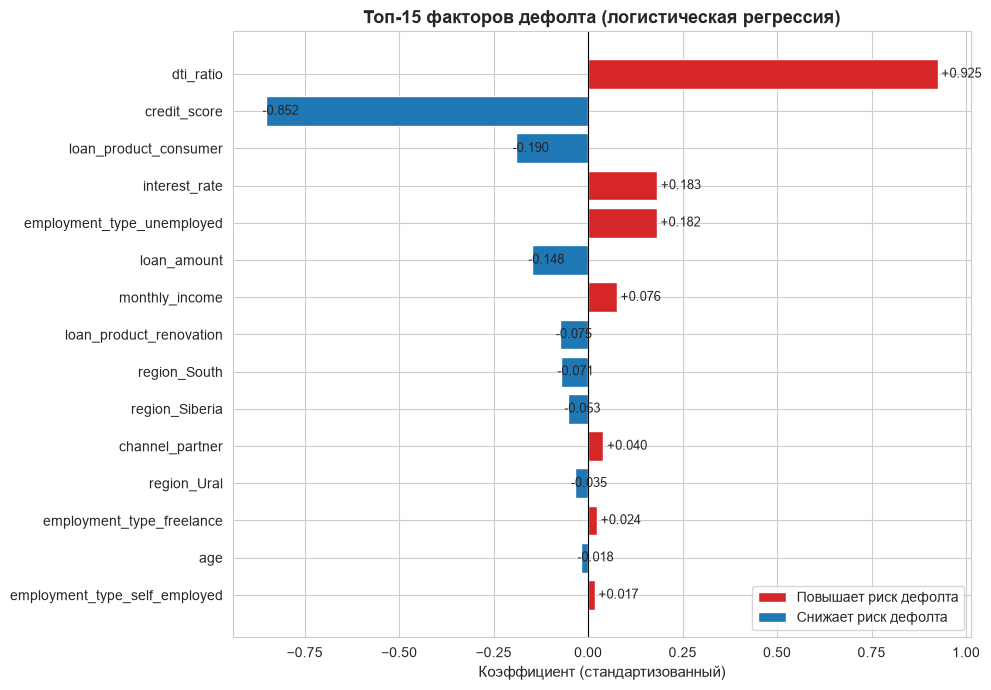

In [26]:
top15 = coef_df.head(15).copy()
# цвет: красный = повышает риск дефолта, синий = снижает
colors = ['#d62728' if c > 0 else '#1f77b4' for c in top15['coef']]

fig, ax = plt.subplots(figsize=(10, 7))
# переворачиваем, чтобы топ-1 был сверху
bars = ax.barh(top15['feature'][::-1], top15['coef'][::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel("Коэффициент (стандартизованный)", fontsize=11)
ax.set_title("Топ-15 факторов дефолта (логистическая регрессия)", fontsize=13, weight='bold')

# подписи значений на барах
for bar, val in zip(bars, top15['coef'][::-1]):
    ax.text(bar.get_width() + 0.01 * (1 if val >= 0 else -1),
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.3f}", va='center', fontsize=9)

# легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#d62728', label='Повышает риск дефолта'),
                   Patch(facecolor='#1f77b4', label='Снижает риск дефолта')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

In [27]:
# Числовые признаки vs бинарная цель: point-biserial корреляция
# (это Пирсон между числом и 0/1) + Welch t-test.
# Выбор метода: цель бинарная, предиктор числовой -> стандартная пара тестов
# "различаются ли средние в группах дефолт/не дефолт".
for col in num_cols:
    r = df[col].corr(df['is_default'])
    g0 = df[df['is_default'] == 0][col]
    g1 = df[df['is_default'] == 1][col]
    t, p = stats.ttest_ind(g0, g1, equal_var=False)
    sig = "значимо" if p < 0.05 else "не значимо"
    print(f"{col:<16} r={r:+.3f} | Welch p={p:.4f} -> {sig}")

age              r=-0.074 | Welch p=0.0000 -> значимо
monthly_income   r=-0.172 | Welch p=0.0000 -> значимо
loan_amount      r=+0.049 | Welch p=0.0007 -> значимо
interest_rate    r=+0.196 | Welch p=0.0000 -> значимо
credit_score     r=-0.434 | Welch p=0.0000 -> значимо
dti_ratio        r=+0.369 | Welch p=0.0000 -> значимо


In [28]:
# Категориальный признак vs бинарная цель -> хи-квадрат тест независимости.
# Частоты большие, условия применимости выполнены.
for col in ['region', 'channel', 'loan_product', 'employment_type', 'gender']:
    table = pd.crosstab(df[col], df['is_default'])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    sig = "значимо" if p < 0.05 else "не значимо"
    print(f"{col:<16} chi2={chi2:>10.2f}  p={p:.4f} -> {sig}")

region           chi2=      4.03  p=0.4024 -> не значимо
channel          chi2=      9.65  p=0.0080 -> значимо
loan_product     chi2=    103.94  p=0.0000 -> значимо
employment_type  chi2=    669.19  p=0.0000 -> значимо
gender           chi2=      2.57  p=0.1091 -> не значимо


In [29]:
import statsmodels.api as sm

# эффект region/channel после контроля остальных переменных.
X_num_s = (df[num_cols] - df[num_cols].mean()) / df[num_cols].std()
X_cat = pd.get_dummies(df[cat_cols], drop_first=True, dtype=int)
X = pd.concat([X_num_s, X_cat], axis=1)

# Интеракция South × partner прямо в регрессии
X['south_x_partner'] = X['region_South'] * X['channel_partner']
X = sm.add_constant(X)

model_sm = sm.Logit(df['is_default'], X).fit(disp=0)

res = pd.DataFrame({'coef': model_sm.params, 'pvalue': model_sm.pvalues}).round(3)

# Самостоятельные факторы: region и channel после контроля
print_title("REGION / CHANNEL ПОСЛЕ КОНТРОЛЯ ПЕРЕМЕННЫХ")
mask_rc = [i for i in res.index if i.startswith(('region_', 'channel_'))]
print(res.loc[mask_rc])

# Интеракция: значим ли член south_x_partner
print_title("ИНТЕРАКЦИЯ SOUTH × PARTNER")
print(res.loc[['region_South', 'channel_partner', 'south_x_partner']])

p_sp = res.loc['south_x_partner', 'pvalue']
print(f"\np-value интеракции: {p_sp:.4f} -> "
      f"{'интеракция значима: сочетание дает дополнительный риск сверх суммы факторов' if p_sp < 0.05 else 'интеракция не значима'}")


--------------------------------------------------------------------------------
REGION / CHANNEL ПОСЛЕ КОНТРОЛЯ ПЕРЕМЕННЫХ
--------------------------------------------------------------------------------
                  coef  pvalue
region_SPb      -0.017   0.877
region_Siberia  -0.147   0.233
region_South    -0.191   0.188
region_Ural     -0.089   0.436
channel_online   0.014   0.875
channel_partner  0.100   0.344

--------------------------------------------------------------------------------
ИНТЕРАКЦИЯ SOUTH × PARTNER
--------------------------------------------------------------------------------
                  coef  pvalue
region_South    -0.191   0.188
channel_partner  0.100   0.344
south_x_partner -0.042   0.866

p-value интеракции: 0.8660 -> интеракция не значима


## 8. Процентный доход и Expected Loss

Считаю упрощенно:
- Процентный доход = все платежи минус тело (только для недефолтных)
- EL = PD × LGD × EAD (базельская формула)
- EAD упрощаю до loan_amount

В реальности нужна детальная модель cash flows с дисконтированием,
учетом partial recovery и тд. Но для оценки порядка сойдет.

In [30]:
# процентный доход
df['interest_income'] = np.where(
    df['is_default'] == 0,
    df['monthly_payment'] * df['loan_term_months'] - df['loan_amount'],
    0  # дефолт — теряем проценты (консервативно)
)

print(f"Суммарный процентный доход: {df['interest_income'].sum():,.0f} руб.")
print("\nNB: это 'грязный' доход без учета cost of funds и операционки")

Суммарный процентный доход: 570,218,087 руб.

NB: это 'грязный' доход без учета cost of funds и операционки


risk_segment  loans  interest_income          EL   net_result  net_result_per_loan
        HIGH   2533     243810283.92 194849929.0  48960354.92              19329.0
         LOW   1025      79732082.40   3005640.0  76726442.40              74855.0
         MED   2430     246675720.64  40203070.0 206472650.64              84968.0


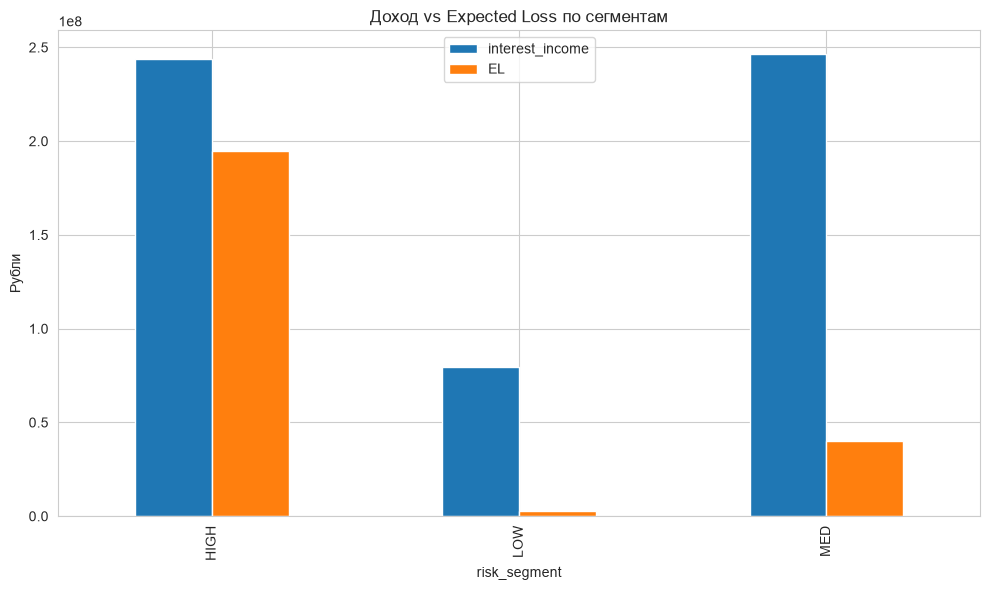

In [31]:
# EL по сегментам
el = df.groupby('risk_segment').agg(
    loans=('loan_id', 'count'),
    PD=('is_default', 'mean'),
    EAD=('loan_amount', 'sum'),
    interest_income=('interest_income', 'sum')
).reset_index()

el['EL'] = (el['PD'] * el['EAD'] * LGD).round(0)
el['net_result'] = el['interest_income'] - el['EL']
el['net_result_per_loan'] = (el['net_result'] / el['loans']).round(0)

print(el[['risk_segment', 'loans', 'interest_income', 'EL', 'net_result', 'net_result_per_loan']].to_string(index=False))

# наглядно: доход vs EL
fig, ax = plt.subplots(figsize=(10, 6))
el.set_index('risk_segment')[['interest_income', 'EL']].plot.bar(stacked=False, ax=ax)
ax.set_title("Доход vs Expected Loss по сегментам")
ax.set_ylabel("Рубли")
plt.tight_layout()
plt.show()

el.to_csv(f"el_by_segment_{AUTHOR}.csv", index=False)

In [32]:
# Смотрим терцили распределений — обоснование порогов
print("Терцили credit_score:")
print(df['credit_score'].quantile([0.33, 0.66]).round(0))

print("\nТерцили dti_ratio:")
print(df['dti_ratio'].quantile([0.33, 0.66]).round(1))

Терцили credit_score:
0.33    600.0
0.66    663.0
Name: credit_score, dtype: float64

Терцили dti_ratio:
0.33    49.1
0.66    61.7
Name: dti_ratio, dtype: float64


In [33]:
# Общий тест: связаны ли сегмент с дефолтом
table = pd.crosstab(df['risk_segment'], df['is_default'])
chi2, p, dof, _ = stats.chi2_contingency(table)
print_title("ОБЩИЙ ТЕСТ: СЕГМЕНТЫ vs ДЕФОЛТ")
print(table)
print(f"\nchi2={chi2:.2f}, p={p:.6f} -> {'сегменты различаются' if p < 0.05 else 'не различаются'}")

# Парные сравнения с поправкой Бонферрони (3 пары -> alpha/3)
print_title("ПАРНЫЕ СРАВНЕНИЯ (Бонферрони, alpha=0.05/3)")
for a, b in [('LOW', 'MED'), ('MED', 'HIGH'), ('LOW', 'HIGH')]:
    sub = df[df['risk_segment'].isin([a, b])]
    t = pd.crosstab(sub['risk_segment'], sub['is_default'])
    chi2_ab, p_ab, _, _ = stats.chi2_contingency(t)
    pd_a = sub[sub['risk_segment'] == a]['is_default'].mean() * 100
    pd_b = sub[sub['risk_segment'] == b]['is_default'].mean() * 100
    sig = "значимо" if p_ab < 0.05 / 3 else "НЕ значимо"
    print(f"{a} vs {b}: PD {pd_a:.1f}% vs {pd_b:.1f}%, p={p_ab:.6f} -> {sig}")


--------------------------------------------------------------------------------
ОБЩИЙ ТЕСТ: СЕГМЕНТЫ vs ДЕФОЛТ
--------------------------------------------------------------------------------
is_default       0    1
risk_segment           
HIGH          1585  948
LOW           1003   22
MED           2201  229

chi2=854.07, p=0.000000 -> сегменты различаются

--------------------------------------------------------------------------------
ПАРНЫЕ СРАВНЕНИЯ (Бонферрони, alpha=0.05/3)
--------------------------------------------------------------------------------
LOW vs MED: PD 2.1% vs 9.4%, p=0.000000 -> значимо
MED vs HIGH: PD 9.4% vs 37.4%, p=0.000000 -> значимо
LOW vs HIGH: PD 2.1% vs 37.4%, p=0.000000 -> значимо


### Обоснование сегментации LOW / MEDIUM / HIGH

**Пороги:** LOW — score ≥ 670 и DTI ≤ 50%; HIGH — score < 600 или DTI > 70%; остальное — MEDIUM.

**Статистическое обоснование:** границы близки к терцилям портфеля
(score: 600 / 663; DTI: 49.1% / 61.7%), то есть деление по естественным квантилям.

**Бизнес-обоснование:** score < 600 — субпрайм-зона, ≥ 670 — прайм-зона;
DTI > 70% — преддефолтная нагрузка (регулятор считает нагрузку выше 50% повышенной).
В HIGH клиент попадает при хотя бы одном красном индикаторе (консервативная логика «ИЛИ»),
в LOW — только при обоих зеленых («И»).

**Подтверждение различий:** общий хи-квадрат χ² = 854.07, p < 0.001;
парные сравнения с поправкой Бонферрони значимы для всех трех пар;
PD монотонно растет: 2.1% → 9.4% → 37.4%.

## 9. План-факт по филиалам

Сравниваю фактические метрики с планами из branch_reference.csv.
Важно: справочник покрывает не все комбинации — это ограничение, отмечаю в выводе.

In [34]:
branch_ref = pd.read_csv('branch_reference.csv')

# план по region × channel
ref_agg = branch_ref.groupby(['region', 'channel']).agg(
    plan_default_rate=('target_default_rate', 'mean'),
    plan_credit_score=('target_avg_credit_score', 'mean'),
    plan_dti=('target_avg_dti', 'mean')
).round(3).reset_index()

# факт
fact = df.groupby(['region', 'channel']).agg(
    fact_loans=('loan_id', 'count'),
    fact_pd=('is_default', 'mean'),
    fact_score=('credit_score', 'mean'),
    fact_dti=('dti_ratio', 'mean')
).round(3).reset_index()

# join — только те сегменты где есть план
pf = fact.merge(ref_agg, on=['region', 'channel'], how='inner')

# отклонения
pf['dev_pd'] = (pf['fact_pd'] - pf['plan_default_rate']).round(3)
pf['dev_score'] = (pf['fact_score'] - pf['plan_credit_score']).round(1)
pf['dev_dti'] = (pf['fact_dti'] - pf['plan_dti']).round(1)

# статусы: PD и DTI — чем ниже тем лучше; score — чем выше тем лучше
pf['pd_status'] = np.where(pf['dev_pd'] <= 0, 'OK', 'BAD')
pf['score_status'] = np.where(pf['dev_score'] >= 0, 'OK', 'BAD')
pf['dti_status'] = np.where(pf['dev_dti'] <= 0, 'OK', 'BAD')

print_title("ПЛАН-ФАКТ (region × channel)")

print(pf[['region', 'channel', 'fact_loans',
          'fact_pd', 'plan_default_rate', 'dev_pd', 'pd_status',
          'fact_score', 'plan_credit_score', 'dev_score', 'score_status',
          'fact_dti', 'plan_dti', 'dev_dti', 'dti_status']].to_string(index=False))


--------------------------------------------------------------------------------
ПЛАН-ФАКТ (region × channel)
--------------------------------------------------------------------------------
 region channel  fact_loans  fact_pd  plan_default_rate  dev_pd pd_status  fact_score  plan_credit_score  dev_score score_status  fact_dti  plan_dti  dev_dti dti_status
 Moscow  branch         636    0.182               0.09   0.092       BAD     641.936              623.0       18.9           OK    56.386      47.5      8.9        BAD
 Moscow  online         690    0.203               0.10   0.103       BAD     642.939              622.0       20.9           OK    58.230      52.7      5.5        BAD
    SPb  branch         443    0.178               0.10   0.078       BAD     639.867              612.0       27.9           OK    53.640      50.4      3.2        BAD
    SPb  online         450    0.191               0.09   0.101       BAD     637.780              616.0       21.8           OK    

In [35]:
# проверяю покрытие справочника
all_comb = set(zip(fact['region'], fact['channel']))
covered = set(zip(pf['region'], pf['channel']))
uncovered = all_comb - covered

print(f"Всего комбинаций: {len(all_comb)}")
print(f"Покрыто планами: {len(covered)}")
print(f"Без плана: {len(uncovered)}")
if uncovered:
    print("\nСегменты без плана:")
    for r, c in sorted(uncovered):
        print(f"  {r} / {c}")
    print("\nВывод: справочник неполный. Для полного анализа нужно дополнить.")

Всего комбинаций: 15
Покрыто планами: 7
Без плана: 8

Сегменты без плана:
  Moscow / partner
  SPb / partner
  Siberia / online
  Siberia / partner
  South / branch
  South / online
  Ural / online
  Ural / partner

Вывод: справочник неполный. Для полного анализа нужно дополнить.


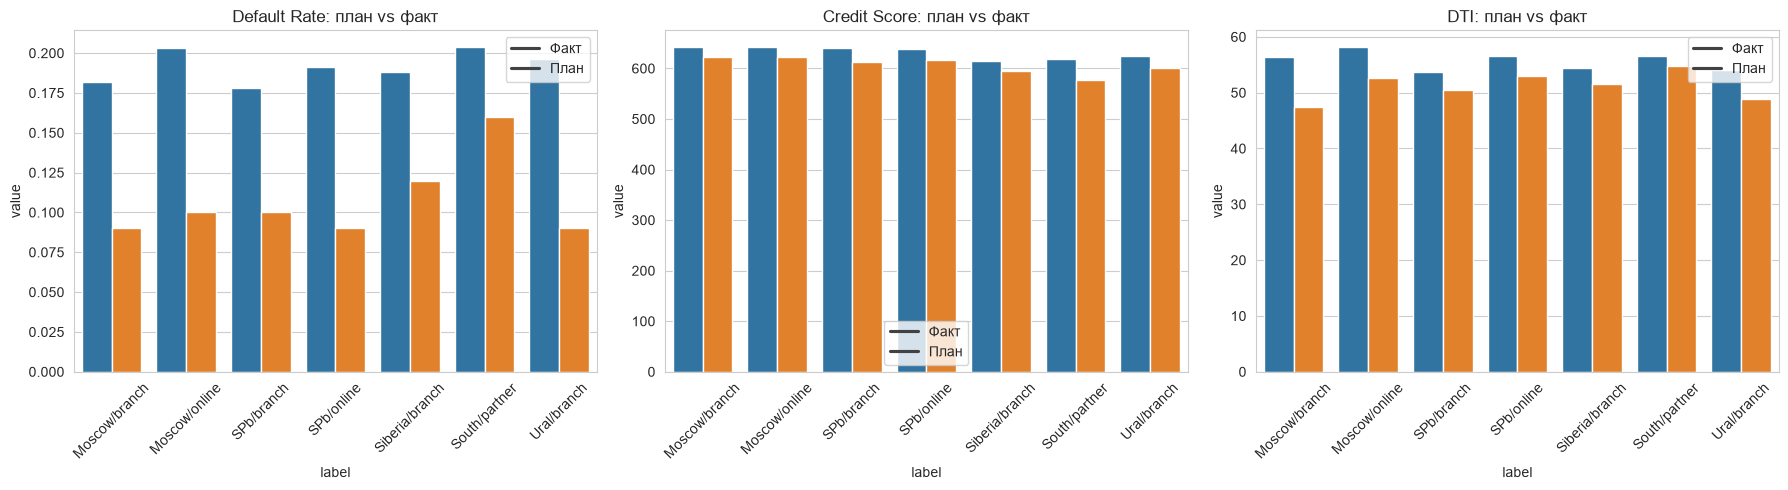

In [36]:
# визуализирую план vs факт
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pf_melted_pd = pf.melt(
    id_vars=['region', 'channel'],
    value_vars=['fact_pd', 'plan_default_rate'],
    var_name='metric', value_name='value'
)
pf_melted_pd['label'] = pf_melted_pd['region'] + '/' + pf_melted_pd['channel']
sns.barplot(x='label', y='value', hue='metric', data=pf_melted_pd, ax=axes[0])
axes[0].set_title("Default Rate: план vs факт")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(['Факт', 'План'])

pf_melted_score = pf.melt(
    id_vars=['region', 'channel'],
    value_vars=['fact_score', 'plan_credit_score'],
    var_name='metric', value_name='value'
)
pf_melted_score['label'] = pf_melted_score['region'] + '/' + pf_melted_score['channel']
sns.barplot(x='label', y='value', hue='metric', data=pf_melted_score, ax=axes[1])
axes[1].set_title("Credit Score: план vs факт")
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['Факт', 'План'])

pf_melted_dti = pf.melt(
    id_vars=['region', 'channel'],
    value_vars=['fact_dti', 'plan_dti'],
    var_name='metric', value_name='value'
)
pf_melted_dti['label'] = pf_melted_dti['region'] + '/' + pf_melted_dti['channel']
sns.barplot(x='label', y='value', hue='metric', data=pf_melted_dti, ax=axes[2])
axes[2].set_title("DTI: план vs факт")
axes[2].tick_params(axis='x', rotation=45)
axes[2].legend(['Факт', 'План'])

plt.tight_layout()
plt.show()

pf.to_csv(f"plan_fact_{AUTHOR}.csv", index=False)

## Выводы

1. **PD портфеля ~20%** — достаточно высокий уровень для розницы.
2. **Безработные** дают PD ~59% — очевидно нужен фильтр на этапе скоринга.
3. **Возраст <25** — повышенный риск (~25% PD vs ~19% в среднем).
4. **Канал partner** статистически значимо хуже других каналов.
5. **South+partner** — конкретная горячая точка, но разница с остальными статистически незначима (p=0.90).
6. **DTI и credit_score** — главные драйверы дефолта по логрегрессии.
7. **Регион сам по себе не значим** (chi2 p=0.40), эффект идет через канал.
8. **HIGH-сегмент** генерирует убытки, LOW и MED — прибыльные.
9. **План-факт**: по PD и DTI почти все филиалы в статусе BAD — кредитная политика системно агрессивнее плана.
10. **Ограничение**: справочник покрывает только 7 из 15 комбинаций.

# Задание 4. Рекомендации по изменению кредитной политики

Выполнила: Стрюкова Анастасия Станиславовна.

Задача: дать не менее 5 рекомендаций по изменению кредитной политики.
Смоделировать портфель с уже примененными рекомендациями.

# 1. Подготовка прогнозной PD.

Прогноз индивидуального PD для всех клиентов

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Обучаем модель на числовых + категориальных признаках
num_cols = ['age', 'monthly_income', 'loan_amount', 'interest_rate', 
            'credit_score', 'dti_ratio', 'loan_term_months', 
            'work_experience_years', 'existing_loans_count']
cat_cols = ['region', 'channel', 'loan_product', 'employment_type']

X_num = df[num_cols].copy()
X_cat = pd.get_dummies(df[cat_cols], drop_first=True, dtype=int)
X = pd.concat([X_num, X_cat], axis=1)
y = df['is_default']

# Запоминаем порядок признаков, чтобы потом применить ко всему df
feature_names = X.columns

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_scaled, y)

# Прогноз вероятности дефолта для КАЖДОГО клиента
df['pred_pd'] = model.predict_proba(X_scaled)[:, 1]

# Ожидаемый EL и ожидаемый доход по каждому клиенту
df['exp_el'] = df['pred_pd'] * df['loan_amount'] * LGD
df['exp_income'] = (1 - df['pred_pd']) * df['interest_income']

# Клиент убыточен, если ожидаемый убыток > ожидаемого дохода
df['is_unprofitable'] = (df['exp_el'] > df['exp_income']).astype(int)

# Экономический cutoff: отклонение прибыльно, только если ожидаемый убыток
# клиента превышает его ожидаемый доход. "Прибыльный" риск банк не режет.
df['profitable_to_reject'] = (df['exp_el'] > df['exp_income']).astype(int)

print(f"Доля клиентов, которых выгодно отклонить: {df['profitable_to_reject'].mean()*100:.2f}%")
print(f"Доля 'убыточных' клиентов по прогнозу: {df['is_unprofitable'].mean()*100:.2f}%")
print(f"Средняя прогнозная PD: {df['pred_pd'].mean()*100:.2f}%")

Доля клиентов, которых выгодно отклонить: 28.26%
Доля 'убыточных' клиентов по прогнозу: 28.26%
Средняя прогнозная PD: 20.02%


# 2. Подготовка фукнции оценки. 

Функция оценки через прогнозную PD

In [38]:
def evaluate_recommendation(mask_reject, rec_name):
    sub = df[mask_reject]
    n_rejected = len(sub)
    defaults_avoided = int(sub['is_default'].sum())
    el_saved = sub['exp_el'].sum()
    income_lost = sub['exp_income'].sum()
    net = el_saved - income_lost
    hit_rate = defaults_avoided / n_rejected * 100 if n_rejected else 0

    return pd.DataFrame([{
        'recommendation': rec_name,
        'n_rejected': n_rejected,
        'defaults_avoided': defaults_avoided,
        'hit_rate_pct': round(hit_rate, 1),
        'el_saved': round(el_saved),
        'income_lost': round(income_lost),
        'net_effect': round(net)
    }])

# 3. Рекомендации.

In [39]:
all_recommendations = []

# 1. Токсичное ядро HIGH-сегмента
mask_1 = (df['risk_segment'] == 'HIGH') & (df['dti_ratio'] > 70) & \
         (df['credit_score'] < 640) & (df['profitable_to_reject'] == 1)
all_recommendations.append(evaluate_recommendation(mask_1, "HIGH: DTI>70% и score<640"))

# 2. Партнерский канал: отсекаем низкий хвост скоринга
mask_2 = (df['channel'] == 'partner') & (df['credit_score'] < 600) & \
         (df['profitable_to_reject'] == 1)
all_recommendations.append(evaluate_recommendation(mask_2, "partner: score<600"))

# 3. South + partner: ужесточение без закрытия канала (правило кейса)
mask_3 = (df['region'] == 'South') & (df['channel'] == 'partner') & \
         (df['dti_ratio'] > 70) & (df['profitable_to_reject'] == 1)
all_recommendations.append(evaluate_recommendation(mask_3, "South+partner: DTI>70%"))

# 4. Автокредиты: низкий скоринг или экстремальная нагрузка
mask_4 = (df['loan_product'] == 'car') & \
         ((df['credit_score'] < 600) | (df['dti_ratio'] > 75)) & \
         (df['profitable_to_reject'] == 1)
all_recommendations.append(evaluate_recommendation(mask_4, "car: score<600 или DTI>75%"))

# 5. Молодые клиенты с критичным DTI
mask_5 = (df['age'] < 25) & (df['dti_ratio'] > 65) & (df['profitable_to_reject'] == 1)
all_recommendations.append(evaluate_recommendation(mask_5, "age<25 и DTI>65%"))

# 4. Вывод результатов с пересечением.


--------------------------------------------------------------------------------
РЕКОМЕНДАЦИИ С BREAK-EVEN ФИЛЬТРОМ
--------------------------------------------------------------------------------
            recommendation  n_rejected  defaults_avoided  hit_rate_pct  el_saved  income_lost  net_effect
 HIGH: DTI>70% и score<640         610               413          67.7  91850357     17055670    74794687
car: score<600 или DTI>75%         480               342          71.2  72953607     12607196    60346412
        partner: score<600         345               234          67.8  32903481      5434487    27468994
          age<25 и DTI>65%         183               140          76.5  22127808      2510987    19616822
    South+partner: DTI>70%          22                14          63.6   2753510       621310     2132200

--------------------------------------------------------------------------------
ИТОГОВЫЙ ЭФФЕКТ (с учетом пересечений)
---------------------------------------------

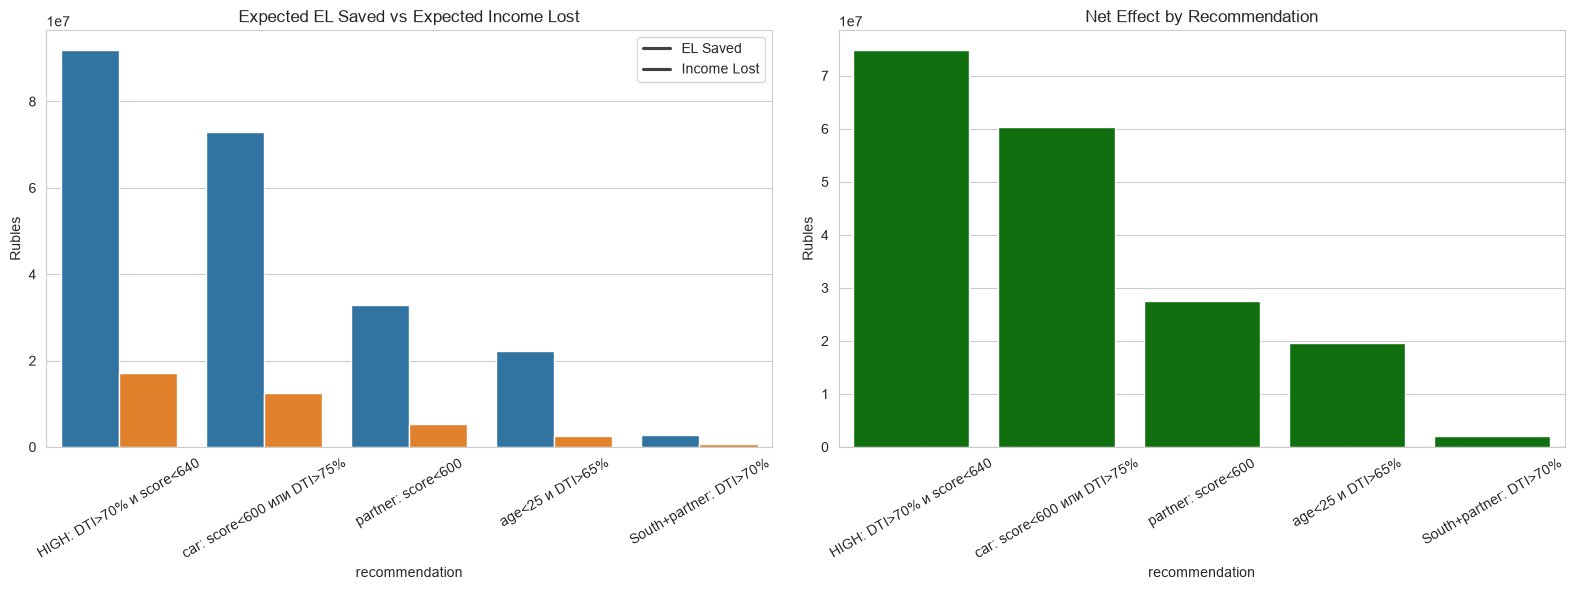


--------------------------------------------------------------------------------
ТАБЛИЦА РЕКОМЕНДАЦИЙ ДЛЯ ОТЧеТА
--------------------------------------------------------------------------------
№               Рекомендация  Отклонено кредитов  Избежано дефолтов  Hit-rate, %  Экономия EL, млн руб.  Потеря дохода, млн руб.  Чистый эффект, млн руб.
1  HIGH: DTI>70% и score<640                 610                413         67.7                   91.9                     17.1                     74.8
2 car: score<600 или DTI>75%                 480                342         71.2                   73.0                     12.6                     60.3
3         partner: score<600                 345                234         67.8                   32.9                      5.4                     27.5
4           age<25 и DTI>65%                 183                140         76.5                   22.1                      2.5                     19.6
5     South+partner: DTI>70%       

In [40]:
summary = pd.concat(all_recommendations, ignore_index=True).sort_values('net_effect', ascending=False)

print_title("РЕКОМЕНДАЦИИ С BREAK-EVEN ФИЛЬТРОМ")

print(summary.to_string(index=False))

# Совокупный эффект с учетом пересечений масок
all_masks = [mask_1, mask_2, mask_3, mask_4, mask_5]
combined = all_masks[0]
for m in all_masks[1:]:
    combined = combined | m

total_el = df.loc[combined, 'exp_el'].sum()
total_inc = df.loc[combined, 'exp_income'].sum()
total_net = total_el - total_inc
n_unique = combined.sum()
n_defaults = int(df.loc[combined, 'is_default'].sum())

print_title("ИТОГОВЫЙ ЭФФЕКТ (с учетом пересечений)")

print(f"Уникальных отклоняемых кредитов: {n_unique}")
print(f"Реальных дефолтов избегаем: {n_defaults}")
print(f"Hit-rate дефолтов среди отклоненных: {n_defaults / n_unique * 100:.1f}%")
print(f"Суммарная экономия EL:  {round(total_el):>14,} руб.")
print(f"Суммарная потеря дохода: {round(total_inc):>13,} руб.")
print(f"Чистый эффект:           {round(total_net):>14,} руб.")
print(f"\nВывод: применение рекомендаций {'улучшит' if total_net > 0 else 'ухудшит'}")
print(f"портфель на {abs(round(total_net)):,} руб. ожидаемого финансового результата.")

summary.to_csv(f"recommendations_summary_{AUTHOR}.csv", index=False)

# Визуализация эффектов
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

summary_melted = summary.melt(
    id_vars=['recommendation'],
    value_vars=['el_saved', 'income_lost'],
    var_name='metric',
    value_name='value'
)
sns.barplot(x='recommendation', y='value', hue='metric', data=summary_melted, ax=axes[0])
axes[0].set_title("Expected EL Saved vs Expected Income Lost")
axes[0].set_ylabel("Rubles")
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(['EL Saved', 'Income Lost'])

sns.barplot(x='recommendation', y='net_effect', data=summary, ax=axes[1], color='green')
axes[1].set_title("Net Effect by Recommendation")
axes[1].set_ylabel("Rubles")
axes[1].tick_params(axis='x', rotation=30)
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

# --- Генерация таблицы рекомендаций из данных ---
# Берем summary (из Этапа 4) и форматируем для отчета

# Добавляем нумерацию
report_table = summary.reset_index(drop=True)
report_table.insert(0, "№", range(1, len(report_table) + 1))

# Переименовываем колонки в русские
report_table = report_table.rename(columns={
    "recommendation": "Рекомендация",
    "n_rejected": "Отклонено кредитов",
    "defaults_avoided": "Избежано дефолтов",
    "hit_rate_pct": "Hit-rate, %",
    "el_saved": "Экономия EL, млн руб.",
    "income_lost": "Потеря дохода, млн руб.",
    "net_effect": "Чистый эффект, млн руб."
})

# Конвертируем денежные суммы в миллионы с округлением
for col in ["Экономия EL, млн руб.", "Потеря дохода, млн руб.", "Чистый эффект, млн руб."]:
    report_table[col] = (report_table[col] / 1_000_000).round(1)

# Итоговая строка (с учетом пересечений через combined маску)
total_row = pd.DataFrame([{
    "№": "",
    "Рекомендация": "ИТОГО (уникальные кредиты)",
    "Отклонено кредитов": n_unique,
    "Избежано дефолтов": n_defaults,
    "Hit-rate, %": round(n_defaults / n_unique * 100, 1),
    "Экономия EL, млн руб.": round(total_el / 1_000_000, 1),
    "Потеря дохода, млн руб.": round(total_inc / 1_000_000, 1),
    "Чистый эффект, млн руб.": round(total_net / 1_000_000, 1)
}])

report_table = pd.concat([report_table, total_row], ignore_index=True)

print_title("ТАБЛИЦА РЕКОМЕНДАЦИЙ ДЛЯ ОТЧеТА")
print(report_table.to_string(index=False))

# Сохранение
report_table.to_csv(f"recommendations_report_table_{AUTHOR}.csv", index=False, encoding="utf-8-sig")

# Задание 5. Проверка отчета Стажеркина.

In [41]:
marks = pd.DataFrame({
    "Цитата ошибки": [
        "Я посчитал, что уровень дефолтов составляет 12,3%, что НИЖЕ целевого показателя в 10%.\nСчитал так: взял сумму колонки is_default и поделил на 100.",
        "Дефолт — это любая просрочка.\nПоэтому я считал дефолты как все строки, где days_past_due > 0.\nПолучилось 28% дефолтов.",
        "Я рассчитал корреляцию loan_amount с is_default и получил r = 0,71 (сильная положительная).\nВывод: большие кредиты нужно выдавать осторожнее.",
        "Связь DTI с дефолтом незначима (p = 0,28),\nпоэтому DTI не стоит использовать как критерий одобрения.",
        "Рекомендую ЗАКРЫТЬ партнерский канал в Южных регионах полностью,\nтак как он убыточен.",
        "При расчете Expected Loss принял LGD = 100%,\nтак как при дефолте банк теряет всю сумму кредита.",
        "Для проверки статистической значимости я использовал t-тест для всех переменных,\nвключая тип занятости и канал (channel, region).",
        "Распределение нормальное, поэтому среднее хорошо его описывает\nи выбросы не влияют на анализ.",
    ],
    "Тип ошибки": [
        "Фактическая и логическая",
        "Методологическая",
        "Фактическая",
        "Фактическая и методологическая",
        "Логическая\n(нарушение бизнес-ограничения кейса)",
        "Методологическая",
        "Методологическая",
        "Фактическая и методологическая",
    ],
    "Правильный вывод или расчет": [
        "PD = sum(is_default) / число строк = 1199 / 5988 ≈ 20,02%, а не 12,3%:\nделение на 100 бессмысленно.\n\n12,3% ВЫШЕ целевых 10%, а не ниже.",
        "По условию кейса дефолт = просрочка 90+ дней.\nКорректная PD = 20,02%. В значение 28% включены технические просрочки 1–89 дней.\nНеверное определение искажает все последующие метрики (PD, EL, сегментацию).",
        "Указанная связь в данных отсутствует.\nСтандартизованный коэффициент логистической регрессии по loan_amount равен −0,148 (слабая отрицательная связь).\nЗначение r = 0,71 противоречит данным портфеля; вывод не подтвержден.",
        "DTI — сильнейший предиктор дефолта в портфеле: стандартизованный коэффициент +0,925 (максимальный по модулю).\nPD сегмента HIGH составляет 37,43% против 2,15% у сегмента LOW.\nИсключение DTI из критериев одобрения лишает банк основного фильтра риска.",
        "Закрытие South + partner запрещено ограничением кейса —\nдля этой комбинации допустимо только ужесточение условий.\nФактический DR South+partner = 20,4% при плане 16%.\n\nКорректное действие: точечное ужесточение порогов одобрения.",
        "Принято LGD = 45% (отраслевое допущение для необеспеченной розницы с учетом частичного возмещения через взыскание).\nПри LGD = 100% EL завышен в 2,2 раза: например, EL сегмента HIGH составляет 194,85 млн руб.\nПри LGD = 45% и около 433 млн руб. при LGD = 100%.",
        "Категориальные переменные это χ²-тест по таблице сопряжённости: channel p = 0,008 (связь присутствует),\nregion p = 0,402 (отсутствует). t-тест по категориальным переменным невалиден.",
        "Распределение дохода правосторонне скошено:\nсреднее = 79 494 руб. > медианы = 77 107 руб.\nВыбросы потребовали ограничения по перцентилям.\n\nПри скошенном распределении среднее искажено —\nнужна медиана. Значение 74 500 руб. получено на сырых\nданных без очистки.",
    ],
})

marks.to_csv("analyst_report_marks.csv", index=False, encoding="utf-8-sig")
marks

,Цитата ошибки,Тип ошибки,Правильный вывод или расчет
0,"Я посчитал, что уровень дефолтов составляет 12...",Фактическая и логическая,PD = sum(is_default) / число строк = 1199 / 59...
1,Дефолт — это любая просрочка.\nПоэтому я счита...,Методологическая,По условию кейса дефолт = просрочка 90+ дней.\...
2,Я рассчитал корреляцию loan_amount с is_defaul...,Фактическая,Указанная связь в данных отсутствует.\nСтандар...
3,"Связь DTI с дефолтом незначима (p = 0,28),\nпо...",Фактическая и методологическая,DTI — сильнейший предиктор дефолта в портфеле:...
4,Рекомендую ЗАКРЫТЬ партнерский канал в Южных р...,Логическая\n(нарушение бизнес-ограничения кейса),Закрытие South + partner запрещено ограничение...
5,"При расчете Expected Loss принял LGD = 100%,\n...",Методологическая,Принято LGD = 45% (отраслевое допущение для не...
6,Для проверки статистической значимости я испол...,Методологическая,Категориальные переменные это χ²-тест по табли...
7,"Распределение нормальное, поэтому среднее хоро...",Фактическая и методологическая,Распределение дохода правосторонне скошено:\nс...
